(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Missing values per column:
 0 total missing values

Describe:
                age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   

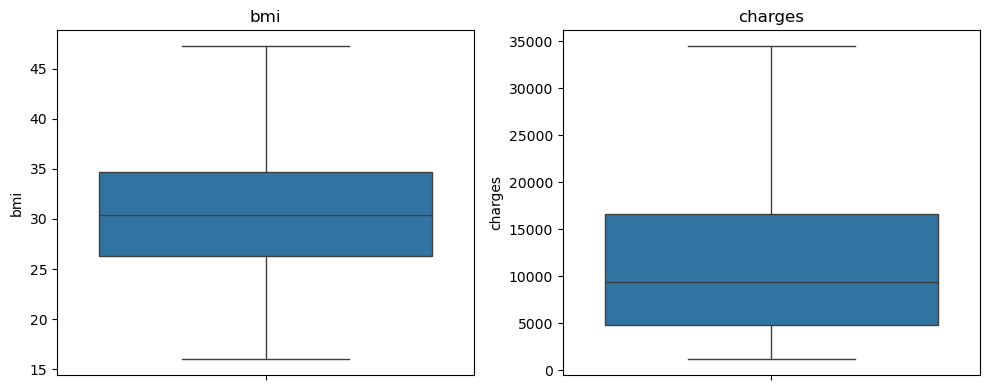

  bmi_category age_group smoker_bmi_risk  has_children  charges_per_age
0   overweight     18-25   moderate_risk             0       888.680211
1        obese     18-25        low_risk             1        95.864017
2        obese     26-35        low_risk             1       158.909357
3       normal     26-35        low_risk             0       666.196079
4   overweight     26-35        low_risk             0       120.839225
(1338, 20)
Highly correlated pairs (>0.80):
('charges_per_age', 'charges', 0.8339482701242216)
Dropped due to multicollinearity: set()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1338 non-null   int64  
 1   bmi                            1338 non-null   float64
 2   children                       1338 non-null   int64  
 3   charges              

In [3]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer

pd.set_option("display.max_columns", None)

df = pd.read_csv(r"C:\Users\Hp\Downloads\insurance.csv")
print(df.shape)
df.head()

# ---- CELL 3: Initial EDA ----
print(df.info())
print("\nMissing values per column:\n", df.isnull().sum().sum(), "total missing values")
print("\nDescribe:\n", df.describe())
print("\nCategorical value counts:")
for col in ["sex", "smoker", "region"]:
    print(f"\n{col}:\n{df[col].value_counts()}")

# < 5%   -> Drop rows
# 5-20%  -> Statistical Imputation (Median for numeric, Mode for categorical)
# > 20%  -> KNN Imputation
def handle_missing_values(data):
    data = data.copy()
    missing_pct = data.isnull().mean() * 100

    for col in data.columns:
        pct = missing_pct[col]
        if pct == 0:
            continue
        if pct < 5:
            data = data.dropna(subset=[col])
        elif 5 <= pct <= 20:
            if data[col].dtype in ["float64", "int64"]:
                data[col] = data[col].fillna(data[col].median())
            else:
                data[col] = data[col].fillna(data[col].mode()[0])
        elif pct > 20:
            if data[col].dtype in ["float64", "int64"]:
                numeric_cols = data.select_dtypes(include=np.number).columns
                imputer = KNNImputer(n_neighbors=5)
                data[numeric_cols] = imputer.fit_transform(data[numeric_cols])
            else:
                data = data.drop(columns=[col])
    return data

df_clean = handle_missing_values(df)
print("Missing values after cleaning:", df_clean.isnull().sum().sum())

outlier_candidates = ["bmi", "charges"]

def cap_outliers_iqr(data, columns):
    data = data.copy()
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        n_outliers = ((data[col] < lower_bound) | (data[col] > upper_bound)).sum()
        data[col] = data[col].clip(lower=lower_bound, upper=upper_bound)
        print(f"{col}: bounds=({lower_bound:.2f}, {upper_bound:.2f}) | outliers capped: {n_outliers}")
    return data

df_clean = cap_outliers_iqr(df_clean, outlier_candidates)

# Visualize before/after
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, outlier_candidates):
    sns.boxplot(y=df_clean[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


df_feat = df_clean.copy()

# Feature 1: BMI category (medical standard bins)
df_feat["bmi_category"] = pd.cut(
    df_feat["bmi"],
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=["underweight", "normal", "overweight", "obese"]
)

# Feature 2: Age group binning
df_feat["age_group"] = pd.cut(
    df_feat["age"],
    bins=[17, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-64"]
)

# Feature 3: Smoker x BMI interaction -> smoking ka effect obesity ke saath compound hota hai
df_feat["smoker_bmi_risk"] = np.where(
    (df_feat["smoker"] == "yes") & (df_feat["bmi"] >= 30), "high_risk",
    np.where(df_feat["smoker"] == "yes", "moderate_risk", "low_risk")
)

# Feature 4 (bonus): Has children flag (binary, simpler signal than count)
df_feat["has_children"] = (df_feat["children"] > 0).astype(int)

# Feature 5 (bonus): Charges per age -> cost efficiency indicator
df_feat["charges_per_age"] = df_feat["charges"] / df_feat["age"]

print(df_feat[["bmi_category", "age_group", "smoker_bmi_risk",
               "has_children", "charges_per_age"]].head())

categorical_cols = df_feat.select_dtypes(include=["object", "category"]).columns.tolist()
df_encoded = pd.get_dummies(df_feat, columns=categorical_cols, drop_first=True)
print(df_encoded.shape)

corr_matrix = df_encoded.select_dtypes(include=np.number).corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = [
    (col, row, upper_triangle.loc[row, col])
    for col in upper_triangle.columns
    for row in upper_triangle.index
    if pd.notnull(upper_triangle.loc[row, col]) and upper_triangle.loc[row, col] > 0.80
]
print("Highly correlated pairs (>0.80):")
for pair in high_corr_pairs:
    print(pair)

target = "charges"
cols_to_drop = set()
for col1, col2, corr_val in high_corr_pairs:
    if col1 == target or col2 == target:
        continue
    if abs(df_encoded[col1].corr(df_encoded[target])) < abs(df_encoded[col2].corr(df_encoded[target])):
        cols_to_drop.add(col1)
    else:
        cols_to_drop.add(col2)

df_encoded = df_encoded.drop(columns=list(cols_to_drop))
print("Dropped due to multicollinearity:", cols_to_drop)


print(df_encoded.info())
df_encoded.to_csv("cleaned_insurance.csv", index=False)
print("Saved -> cleaned_insurance.csv")